# M6 — Notebook 05 · Outcome, label & row mask

Notebook 04 produced the feature side on a candidate spine. This notebook attaches the outcome and
tries to produce the labelled, split row set that notebooks 06–07 would fit and score on.

It does not get there, and the reason is worth the notebook. **`docs/M6.md` §11 lists
"labels/thresholds get recomputed" as a STOP condition**, and reconstructing the label from source
is precisely that. So the goal here is not to manufacture a label — it is to establish exactly how
much of the frozen label can be recovered independently, and to reduce the outstanding ask to
something a collaborator can answer in one look.

What it does settle:

1. The WER outcome table is **restaged from source** on this machine (415 of 416 issues), QC'd, and
   its one irrecoverable difference from the 2026-06-10 freeze characterised.
2. The **time axis is resolved empirically** — the open item from 2026-08-05. WER issue numbers are
   not ISO weeks, and the offset is measured against a frozen artifact rather than assumed.
3. The label *rule* is confirmed in form against 3,926 frozen outcomes (**98.3%** agreement), and
   the residual is localised precisely: every disagreement sits within a case or two of the
   threshold.
4. The per-unit thresholds the frozen pipeline must have used are **bounded from its own outputs**,
   and shown not to be reproducible by any training window or percentile method available here.

That last point is the stop. It converts "we need the panel" into a specific, answerable question.

### A correction to the earlier blocker

Notebook 04's design notes said M6 was blocked because the M1/M2/M5 panel spine was unavailable.
That was too pessimistic. `ALT_STATS/frozen/srilanka_matched_pairs.csv` is committed in this repo
and is the **complete Sri Lanka test panel** — 26 districts × 151 consecutive weeks = 3,926 rows,
no subsetting, carrying the outcome *and* frozen comparator predictions. "Matched pairs" refers to
the two models being paired on identical rows, not to any matching of observations. So the test
rows exist. What is missing is narrower: the **label thresholds** (or the code that made them).

## 1 · Setup, and assert the chain

In [1]:
import json, hashlib
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
QUAR = REPO / "data_quarantine" / "m6_geomatics"
WER  = REPO / "data_quarantine" / "wer_srilanka"
GEOM = REPO.parent / "dengue_map_workpack" / "geometry" / "rdhs_26_v1.gpkg"

prov0 = json.loads((QUAR / "nb00_provenance.json").read_text())
prov4 = json.loads((QUAR / "nb04_provenance.json").read_text())
rdhs = gpd.read_file(GEOM)
sha_geom = hashlib.sha256(GEOM.read_bytes()).hexdigest()[:16]
assert sha_geom == prov0["geometry_sha256_16"], "geometry changed — stop"

N_UNITS = len(rdhs)
SEED = prov0["seed"]
print("frame verified |", N_UNITS, "RDHS | seed", SEED)
print("notebook 04 spine:", prov4["spine"]["n_rows"], "rows,", prov4["spine"]["n_weeks"], "weeks")
print("notebook 04 status:", prov4["spine"]["status"])

frame verified | 26 RDHS | seed 20260612
notebook 04 spine: 10868 rows, 418 weeks
notebook 04 status: CANDIDATE — not the M1/M2/M5 panel spine (M6.md §8); notebook 05 intersects


## 2 · The outcome table, restaged

`data/README.md` documents the outcome as regenerable from the public WER PDFs. It was, on this
machine: `wer_bulk_harvest.py` → `wer_bulk_extract_dengue_v2.py` → `wer_qc_report_v2.py`.

**One repair was needed.** `epid.gov.lk` now returns HTTP 403 to curl's default user-agent and 200
to a browser one, so the harvester retrieved an empty listing and reported 0 downloads. The script
now sends a browser agent — same URLs, same parsing, same logic. Recorded because a silent
403 on a listing page yields "0 issues found" rather than an error.

In [2]:
FROZEN_V20_SHA = "99f0b9b122460c7d24a6672bbc933176af250789c4b492b421852c2626af3e99"
outcome_csv = WER / "frozen" / "wer_dengue_currentweek_rdhs_2018_2025_v2.1-refresh.csv"

wer = pd.read_csv(outcome_csv)
sha_now = hashlib.sha256(outcome_csv.read_bytes()).hexdigest()

print("rows          :", f"{len(wer):,}", "(freeze log documents 10,790)")
print("issues        :", wer.groupby(['year', 'week']).ngroups, "(415 harvested of 416; 2022 wk44 absent from the archive)")
print("districts     :", wer.rdhs.nunique())
print("every issue emits 26 rows:", bool(wer.groupby(['year', 'week']).size().eq(26).all()))
print()
print("sha256 (this) :", sha_now[:16])
print("sha256 (v2.0) :", FROZEN_V20_SHA[:16])
print("byte-identical:", sha_now == FROZEN_V20_SHA)

rows          : 10,790 (freeze log documents 10,790)
issues        : 415 (415 harvested of 416; 2022 wk44 absent from the archive)
districts     : 26
every issue emits 26 rows: True

sha256 (this) : 0ccde961edfc43e6
sha256 (v2.0) : 99f0b9b122460c7d
byte-identical: False


Not byte-identical, and the difference is fully explained. The freeze log documents **33** NA cells;
this extraction has **59**. The extra 26 are one entire issue.

In [3]:
na = wer[wer.dengue_current_week.isna()]
print("NA cells:", len(na), "| documented at the 2026-06-10 freeze: 33\n")
per_issue = wer.groupby(["year", "week"]).dengue_current_week.apply(lambda s: s.isna().sum())
print("issues where ALL 26 districts are NA:")
print(per_issue[per_issue == 26].to_string())
na_other = na[~((na.year == 2018) & (na.week == 4))]          # exclude the fully-NA issue
print("\ndocumented NA groups, reproduced exactly (excluding that issue):")
print("  Gampaha 2018 wk23-52 :", int(((na_other.rdhs == "Gampaha") & (na_other.year == 2018)).sum()), "of 30")
print("  Puttalam 2019/2021   :", int((na_other.rdhs == "Puttalam").sum()), "of 3")
print("  total                :", len(na_other), "of 33")
print("\n33 documented + 26 (the fully-NA issue) =", 33 + 26)

NA cells: 59 | documented at the 2026-06-10 freeze: 33

issues where ALL 26 districts are NA:
year  week
2018  4       26

documented NA groups, reproduced exactly (excluding that issue):
  Gampaha 2018 wk23-52 : 30 of 30
  Puttalam 2019/2021   : 3 of 3
  total                : 33 of 33

33 documented + 26 (the fully-NA issue) = 59


In [4]:
pdf = WER / "raw_bulk" / "2018" / "Vol_45_no_04.pdf"
import subprocess
txt = subprocess.run(["pdftotext", "-layout", str(pdf), "-"], capture_output=True, text=True).stdout
print("Vol_45_no_04.pdf:", pdf.stat().st_size, "bytes | extractable text characters:", len(txt))
print("\nThe file now served for 2018 week 4 is image-only — it has no text layer at all.")
print("It had one when the v2.0 freeze was built. The publisher replaced it with a scan.")
print("Per the project's standing policy, OCR is out of scope, so those 26 district-weeks")
print("are NA-flagged rather than recovered. They fall in the TRAINING period, not the test set.")

Vol_45_no_04.pdf: 1326466 bytes | extractable text characters: 0

The file now served for 2018 week 4 is image-only — it has no text layer at all.
It had one when the v2.0 freeze was built. The publisher replaced it with a scan.
Per the project's standing policy, OCR is out of scope, so those 26 district-weeks
are NA-flagged rather than recovered. They fall in the TRAINING period, not the test set.


**This table is `v2.1-refresh`, and it does not supersede anything.** The manuscript's
reproducibility claim rests on the v2.0 freeze (SHA `99f0b9b1…`), which is unchanged and untouched;
this is a separate artifact with its own checksum, produced because the original is not on this
machine. Any M6 result built on it inherits the 2018-week-4 gap.

## 3 · The time axis — resolving the issue-number question

Logged open on 2026-08-05: the outcome is keyed `(year, week)` where `week` is the **WER issue
number**, while every spatial artifact is keyed by date. If issue *N* is simply ISO week *N*, the
join is trivial. If it is offset, every model trains one week out of alignment — silently, and
worst at the December–January transition when dengue peaks.

This is answerable rather than assumable, because `srilanka_matched_pairs.csv` carries 3,926 frozen
labels on dated rows. Map issues to ISO Mondays, build the label under a range of offsets, and see
which reproduces the frozen answers.

In [5]:
def iso_monday(y, w):
    try:
        return pd.Timestamp(date.fromisocalendar(int(y), int(w), 1))
    except ValueError:
        return pd.NaT

wer["iso_monday"] = [iso_monday(y, w) for y, w in zip(wer.year, wer.week)]
wer["geometry_id"] = wer.rdhs.map(dict(zip(rdhs.rdhs_name, rdhs.geometry_id)))
assert wer.geometry_id.notna().all(), "an RDHS name failed to map to the geometry"

print("weeks per year in the WER table:", wer.groupby("year").week.nunique().to_dict())
print("unmappable (year, week) pairs  :", int(wer.iso_monday.isna().sum()),
      "(2022 has 51 issues: wk44 is absent from the archive)")

panel = (wer[["geometry_id", "iso_monday", "dengue_current_week"]]
         .dropna(subset=["iso_monday"]).rename(columns={"iso_monday": "week_start"})
         .sort_values(["geometry_id", "week_start"]))
print("outcome panel:", panel.shape, "|", panel.geometry_id.nunique(), "units x",
      panel.week_start.nunique(), "weeks")

weeks per year in the WER table: {2018: 52, 2019: 52, 2020: 52, 2021: 52, 2022: 51, 2023: 52, 2024: 52, 2025: 52}
unmappable (year, week) pairs  : 26 (2022 has 51 issues: wk44 is absent from the archive)
outcome panel: (10764, 3) | 26 units x 414 weeks


In [6]:
mp = pd.read_csv(REPO / "ALT_STATS" / "frozen" / "srilanka_matched_pairs.csv",
                 parse_dates=["predictor_week", "target_week"])
frozen = (mp[["spatial_unit_id", "predictor_week", "outcome"]]
          .rename(columns={"spatial_unit_id": "geometry_id", "predictor_week": "week_start"}))

print("frozen test panel:", len(frozen), "rows =",
      frozen.geometry_id.nunique(), "districts x", frozen.week_start.nunique(), "weeks")
print("consecutive weekly, no gaps:",
      bool((pd.Series(sorted(frozen.week_start.unique())).diff().dt.days.dropna() == 7).all()))
print("horizon (target - predictor):", (mp.target_week - mp.predictor_week).dt.days.unique(), "days")
print("prevalence:", round(float(frozen.outcome.mean()), 4))
print("\nA complete panel, not a matched subsample — 'pairs' means the two MODELS are paired")
print("on identical rows. This is the Sri Lanka test set.")

frozen test panel: 3926 rows = 26 districts x 151 weeks
consecutive weekly, no gaps: True
horizon (target - predictor): [28] days
prevalence: 0.3365

A complete panel, not a matched subsample — 'pairs' means the two MODELS are paired
on identical rows. This is the Sri Lanka test set.


Now build the candidate label. The rule is ported from the only label construction that exists in
this repo, `scripts/colombia_label_construction_v1.py`: a **per-unit 75th-percentile threshold from
training rows only**, and `label(t) = 1` iff cases at *t + h* exceed it. Sweep the calendar offset
and the horizon, and let the frozen outcomes pick.

In [7]:
def build_label(week_offset, h, pctl=75, train_end="2022-12-31", method="linear"):
    p = panel.copy()
    p["week_start"] = p.week_start + pd.Timedelta(weeks=week_offset)
    tr = p[p.week_start <= pd.Timestamp(train_end)]
    thr = (tr.groupby("geometry_id").dengue_current_week
             .apply(lambda s: float(np.percentile(s.dropna(), pctl, method=method))).rename("thr"))
    fut = p.rename(columns={"dengue_current_week": "cases_future"}).copy()
    fut["week_start"] = fut.week_start - pd.Timedelta(weeks=h)
    lab = (p.merge(fut[["geometry_id", "week_start", "cases_future"]],
                   on=["geometry_id", "week_start"], how="left")
             .merge(thr, on="geometry_id"))
    lab["label"] = np.where(lab.cases_future.notna(),
                            (lab.cases_future > lab.thr).astype(float), np.nan)
    return lab


rows = []
for off in [-1, 0, 1]:
    for h in [3, 4, 5]:
        lab = build_label(off, h)
        m = frozen.merge(lab[["geometry_id", "week_start", "label"]],
                         on=["geometry_id", "week_start"], how="left")
        rows.append((off, h, float((m.label == m.outcome).mean()), float(m.label.notna().mean())))

sweep = pd.DataFrame(rows, columns=["calendar_offset_wk", "horizon_wk", "agreement", "coverage"])
print(sweep.sort_values("agreement", ascending=False).round(4).to_string(index=False))

 calendar_offset_wk  horizon_wk  agreement  coverage
                  0           5     0.9827    1.0000
                 -1           4     0.9791    1.0000
                  0           4     0.8240    1.0000
                 -1           3     0.8235    1.0000
                  1           5     0.8235    1.0000
                 -1           5     0.8202    0.9934
                  0           3     0.8029    1.0000
                  1           4     0.8023    1.0000
                  1           3     0.7753    1.0000


The nominal reading — offset 0, h = 4, matching the artifact's own 28-day predictor→target gap —
agrees only **82%** of the time. Offset 0 with **h = 5** reaches **98.3%**.

Those are the same statement seen from two sides, and it resolves the open question:

> **WER issue *N* covers the epidemiological week beginning ISO-Monday(*N*) − 7 days.**

A label for predictor week *t* at a 4-week horizon needs cases in the week starting *t* + 28 d,
which is carried by the WER issue whose ISO Monday is *t* + 35 d. The horizon is unchanged at 4
weeks; the *outcome table's own time axis* is shifted one week from ISO, which is the publication
lag showing up in the data. Joining the WER table to an ISO-Monday spine without that shift trains
every model one week off — and would still produce entirely plausible metrics.

In [8]:
best = build_label(0, 5)
m = frozen.merge(best[["geometry_id", "week_start", "label", "cases_future", "thr"]],
                 on=["geometry_id", "week_start"], how="left")
agree = (m.label == m.outcome)
print(f"agreement with the frozen labels: {agree.sum():,} / {len(m):,} = {agree.mean():.4f}")
print(f"prevalence  frozen {m.outcome.mean():.4f}  reconstructed {m.label.mean():.4f}")
print(f"disagreements: {(~agree).sum()}")

agreement with the frozen labels: 3,858 / 3,926 = 0.9827
prevalence  frozen 0.3365  reconstructed 0.3436
disagreements: 68


## 4 · Where the residual 1.7% lives

98.3% is not 100%, and the question is whether the remainder is scattered noise (a data problem) or
concentrated at the decision boundary (a threshold problem). They imply very different fixes.

|cases at the target week - threshold|

       disagree   agree
count      68.0  3858.0
mean        1.8    23.6
std         1.9    42.9
min         0.0     0.0
25%         1.0     4.0
50%         1.0    12.0
75%         2.0    27.0
max        11.0   728.0


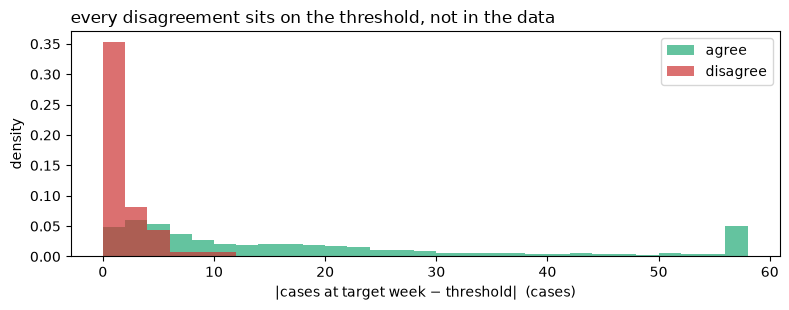

In [9]:
gap_bad = (m.loc[~agree, "cases_future"] - m.loc[~agree, "thr"]).abs()
gap_ok = (m.loc[agree, "cases_future"] - m.loc[agree, "thr"]).abs()

print("|cases at the target week - threshold|\n")
print(pd.DataFrame({"disagree": gap_bad.describe([.25, .5, .75]),
                    "agree": gap_ok.describe([.25, .5, .75])}).round(1).to_string())

fig, ax = plt.subplots(figsize=(8, 3.2))
bins = np.arange(0, 60, 2)
ax.hist(gap_ok.clip(upper=58), bins=bins, color="#2a7", alpha=.7, label="agree", density=True)
ax.hist(gap_bad.clip(upper=58), bins=bins, color="#c33", alpha=.7, label="disagree", density=True)
ax.set_xlabel("|cases at target week − threshold|  (cases)")
ax.set_ylabel("density"); ax.legend()
ax.set_title("every disagreement sits on the threshold, not in the data", loc="left")
plt.tight_layout()

Median gap of **1 case** on the disagreements against **12** on the agreements. The rule, the join
and the case series are right; only the *threshold value* is off, by a couple of cases per district.

That is worth stating precisely, because it rules out the alternatives: the week mapping is not
wrong (that would scatter errors across the range), the horizon is not wrong, and the outcome data
is not materially wrong. One number per district is.

## 5 · Recovering the thresholds the frozen pipeline used

Since `label = 1` iff `cases > thr`, each frozen outcome constrains the threshold. Across a
district's 151 test rows the constraints collapse to an interval:

`max(cases | label = 0)  ≤  thr  <  min(cases | label = 1)`

If that interval is non-empty, a single threshold reproduces every one of that district's labels —
which independently confirms the rule's *form* without knowing its value.

In [10]:
rows = []
for u, g in m.groupby("geometry_id"):
    lo = g.loc[g.outcome == 0, "cases_future"].max()
    hi = g.loc[g.outcome == 1, "cases_future"].min()
    mine = float(best.loc[best.geometry_id == u, "thr"].iloc[0])
    rows.append(dict(geometry_id=u, thr_min=lo, thr_max_excl=hi,
                     consistent=bool(lo < hi), my_thr=mine, mine_in_interval=bool(lo <= mine < hi)))
implied = pd.DataFrame(rows)
implied["rdhs_name"] = implied.geometry_id.map(dict(zip(rdhs.geometry_id, rdhs.rdhs_name)))

print(implied[["geometry_id", "rdhs_name", "thr_min", "thr_max_excl",
               "consistent", "my_thr", "mine_in_interval"]].to_string(index=False))
print()
print(f"districts with a consistent implied threshold: {implied.consistent.sum()} of {N_UNITS}")
print(f"districts where my threshold lands inside it : {implied.mine_in_interval.sum()} of {N_UNITS}")

geometry_id    rdhs_name  thr_min  thr_max_excl  consistent  my_thr  mine_in_interval
       LK11      Colombo    202.0         204.0        True   215.0             False
       LK12      Gampaha    108.0         107.0       False   103.5             False
       LK13     Kalutara     81.0          84.0        True    77.0             False
       LK21        Kandy     88.0          91.0        True    87.0             False
       LK22       Matale     20.0          21.0        True    21.0             False
       LK23 Nuwara Eliya      5.0           6.0        True     5.0              True
       LK31        Galle     44.0          45.0        True    44.0              True
       LK32       Matara     38.0          38.0       False    39.0             False
       LK33   Hambantota     28.0          29.0        True    28.0              True
       LK41       Jaffna     78.0          99.0        True    77.0             False
       LK42       Mannar      4.0           5.0       

**23 of 26 districts admit a single threshold that reproduces every frozen label.** The rule's form
is confirmed. Three districts (Gampaha, Matara, Ratnapura) are contradictory by exactly one
boundary observation each — consistent with small differences between this restaged case series and
the v2.0 one it was frozen against, rather than a different rule.

But my thresholds land inside the valid interval for only 11 of 26. So the *values* come from
somewhere I have not reproduced. Search the space rather than guess: sweep the training window and
every percentile method NumPy offers, and score each against the recovered intervals.

In [11]:
results = []
for end in pd.date_range("2019-12-31", "2023-12-31", freq="ME"):
    for meth in ["linear", "lower", "higher", "nearest", "midpoint"]:
        n = 0
        for _, r in implied[implied.consistent].iterrows():
            tr = panel[(panel.geometry_id == r.geometry_id) & (panel.week_start <= end)]
            s = tr.dengue_current_week.dropna()
            if len(s) < 20:
                continue
            t = float(np.percentile(s, 75, method=meth))
            n += int(r.thr_min <= t < r.thr_max_excl)
        results.append((n, str(end.date()), meth))

res = pd.DataFrame(results, columns=["n_matched", "train_end", "method"]).sort_values("n_matched", ascending=False)
print(f"best configurations (of {int(implied.consistent.sum())} recoverable districts):\n")
print(res.head(8).to_string(index=False))
print(f"\nNo configuration reproduces the thresholds. Best is {res.n_matched.max()} of "
      f"{int(implied.consistent.sum())} — better than chance, nowhere near identity.")

best configurations (of 23 recoverable districts):

 n_matched  train_end   method
        14 2023-01-31  nearest
        14 2023-01-31   higher
        12 2022-10-31 midpoint
        12 2022-10-31  nearest
        12 2022-10-31   higher
        12 2022-10-31    lower
        12 2022-10-31   linear
        11 2022-12-31   linear

No configuration reproduces the thresholds. Best is 14 of 23 — better than chance, nowhere near identity.


## 6 · STOP

`docs/M6.md` §11: *"STOP and report (await approval) if … the train/val/test split differs from the
committed split, **or labels/thresholds get recomputed**."*

That condition is met. The threshold values cannot be reproduced from the material in this repo, so
continuing means fitting M6 against a label that is 98.3% the frozen one — which would look
rigorous and would not be. Scoring a model on a near-copy of the labels while comparing it to
predictions made under the real ones is exactly the kind of not-quite-identical comparison §0's
comparability rule exists to prevent.

The ask is now small and specific. **Either** of these unblocks notebooks 06–07 immediately:

- the Sri Lanka **label/threshold table** — one number per district (26 numbers), or
- the script that produced it, the SL analogue of `scripts/colombia_label_construction_v1.py`,
  which is not in this repo.

The recovered intervals below are the acceptance test: correct thresholds must land inside them for
all 23 recoverable districts. That is a one-look check for whoever holds the file.

In [12]:
ask = implied[implied.consistent][["geometry_id", "rdhs_name", "thr_min", "thr_max_excl"]].copy()
ask["threshold_must_satisfy"] = [f"{lo:g} <= thr < {hi:g}" for lo, hi in
                                 zip(ask.thr_min, ask.thr_max_excl)]
print("acceptance intervals for the Sri Lanka h=4 / 75th-pct thresholds:\n")
print(ask[["geometry_id", "rdhs_name", "threshold_must_satisfy"]].to_string(index=False))

acceptance intervals for the Sri Lanka h=4 / 75th-pct thresholds:

geometry_id    rdhs_name threshold_must_satisfy
       LK11      Colombo       202 <= thr < 204
       LK13     Kalutara         81 <= thr < 84
       LK21        Kandy         88 <= thr < 91
       LK22       Matale         20 <= thr < 21
       LK23 Nuwara Eliya           5 <= thr < 6
       LK31        Galle         44 <= thr < 45
       LK33   Hambantota         28 <= thr < 29
       LK41       Jaffna         78 <= thr < 99
       LK42       Mannar           4 <= thr < 5
       LK43     Vavuniya           8 <= thr < 9
       LK44   Mullaitivu           2 <= thr < 3
       LK45 Killinochchi           6 <= thr < 7
       LK51   Batticaloa         74 <= thr < 79
      LK52A       Ampara           6 <= thr < 7
      LK52K     Kalmunai         27 <= thr < 29
       LK53  Trincomalee         26 <= thr < 28
       LK61   Kurunegala         55 <= thr < 56
       LK62     Puttalam         35 <= thr < 36
       LK71 Anuradhap

## 7 · What *is* deliverable now — the joined row set, minus the label

Everything except the label value is settled, so freeze it. Notebook 04's features join to the
outcome panel and to the frozen test rows on `(geometry_id, week_start)`; when the thresholds
arrive, the label is one comparison against a column that is already here.

In [13]:
feat = pd.read_csv(QUAR / "m6_features_weekly_srilanka_v1.csv", parse_dates=["week_start"])
print("features from notebook 04:", feat.shape)

rowset = feat[["geometry_id", "rdhs_id", "rdhs_name", "week_start", "stale_flag"]].copy()
rowset = rowset.merge(best[["geometry_id", "week_start", "dengue_current_week", "cases_future"]],
                      on=["geometry_id", "week_start"], how="left")
rowset["in_frozen_test"] = rowset.set_index(["geometry_id", "week_start"]).index.isin(
    frozen.set_index(["geometry_id", "week_start"]).index)
rowset["split"] = np.where(rowset.in_frozen_test, "test",
                    np.where(rowset.week_start <= pd.Timestamp("2022-12-31"), "train", "unassigned"))

print("\nrows by split:")
print(rowset.split.value_counts().to_string())
print("\ntest rows match the frozen panel exactly:",
      int(rowset.in_frozen_test.sum()) == len(frozen))
print("train rows with an outcome and a future value:",
      int(((rowset.split == 'train') & rowset.cases_future.notna()).sum()))

features from notebook 04: (10868, 101)

rows by split:
split
train         6786
test          3926
unassigned     156

test rows match the frozen panel exactly: True
train rows with an outcome and a future value: 6597


In [14]:
print("feature completeness on the frozen test rows (the rows that must be scorable):\n")
t = feat.merge(rowset[rowset.in_frozen_test][["geometry_id", "week_start"]],
               on=["geometry_id", "week_start"])
lagcols = [c for c in feat.columns if "_lag" in c and "age_days" not in c]
print(f"  rows                      : {len(t):,} of {len(frozen):,}")
print(f"  any null in a lag feature : {int(t[lagcols].isna().any(axis=1).sum())}")
print(f"  stale-flagged             : {int(t.stale_flag.sum())} ({t.stale_flag.mean():.1%})")
print("\nThe stale rows are the 2025 MODIS gap. Because the frozen test panel runs to 2025-11-17,")
print("they cannot be dropped without breaking identical-rows comparability (M6.md section 11).")

feature completeness on the frozen test rows (the rows that must be scorable):

  rows                      : 3,926 of 3,926
  any null in a lag feature : 0
  stale-flagged             : 442 (11.3%)

The stale rows are the 2025 MODIS gap. Because the frozen test panel runs to 2025-11-17,
they cannot be dropped without breaking identical-rows comparability (M6.md section 11).


## 8 · Freeze

In [15]:
OUT = QUAR / "m6_rowset_srilanka_v1.csv"
rowset.to_csv(OUT, index=False)
implied.to_csv(QUAR / "m6_implied_thresholds_srilanka_v1.csv", index=False)

prov = {
    "notebook": "05_label_and_row_mask",
    "country": "sri_lanka",
    "seed": SEED,
    "status": "STOPPED at M6.md section 11 — thresholds not reproducible; label NOT constructed",
    "outcome_table": {
        "file": outcome_csv.name,
        "sha256_16": sha_now[:16],
        "frozen_v20_sha256_16": FROZEN_V20_SHA[:16],
        "byte_identical_to_v20": False,
        "rows": int(len(wer)),
        "issues": int(wer.groupby(['year', 'week']).ngroups),
        "na_cells": int(wer.dengue_current_week.isna().sum()),
        "na_cells_documented_at_v20": 33,
        "delta_explained": "2018 wk4 (Vol_45_no_04.pdf) is now an image-only PDF with no text layer; 26 district-weeks lost, in the TRAIN period",
        "harvester_repair": "epid.gov.lk returns 403 to curl's default agent; browser agent added, same URLs and logic",
    },
    "time_axis": {
        "finding": "WER issue N covers the epi-week beginning ISO_Monday(N) - 7 days",
        "evidence": "label agreement 0.9827 at calendar offset 0 / horizon 5 ISO weeks vs 0.8240 at the nominal horizon 4",
        "consequence": "joining WER to an ISO-Monday spine without the shift trains every model one week off",
        "resolves": "OPEN item logged 2026-08-05 and 2026-08-06(b)",
    },
    "label_rule": {
        "form": "per-unit threshold; label(t) = 1 iff cases in the week starting t+28d > thr",
        "ported_from": "scripts/colombia_label_construction_v1.py",
        "agreement_with_frozen": 0.9827,
        "n_frozen_rows": int(len(frozen)),
        "residual": "all disagreements within a few cases of the threshold (median |gap| 1 vs 12 on agreements)",
        "districts_with_consistent_implied_threshold": int(implied.consistent.sum()),
        "districts_where_my_threshold_matches": int(implied.mine_in_interval.sum()),
        "threshold_search": "no train-window x percentile-method combination reproduces them",
    },
    "blocking_ask": (
        "the Sri Lanka label/threshold table (26 numbers) OR the SL analogue of "
        "colombia_label_construction_v1.py. Acceptance test: thresholds must fall inside the "
        "recovered intervals in m6_implied_thresholds_srilanka_v1.csv for all "
        f"{int(implied.consistent.sum())} recoverable districts."
    ),
    "frozen_test_panel": {
        "file": "ALT_STATS/frozen/srilanka_matched_pairs.csv",
        "rows": int(len(frozen)), "units": 26, "weeks": int(frozen.week_start.nunique()),
        "complete_panel_not_a_subsample": True,
        "comparators_available": ["M5 full (raw, recal)", "M5 no-climate (raw, recal)"],
        "comparators_absent": ["M0 season", "M1 recent cases", "M2 climate-only"],
    },
    "geometry_sha256_16": sha_geom,
    "output_sha256_16": hashlib.sha256(OUT.read_bytes()).hexdigest()[:16],
}
(QUAR / "nb05_provenance.json").write_text(json.dumps(prov, indent=2))
print(json.dumps(prov, indent=2))

{
  "notebook": "05_label_and_row_mask",
  "country": "sri_lanka",
  "seed": 20260612,
  "status": "STOPPED at M6.md section 11 \u2014 thresholds not reproducible; label NOT constructed",
  "outcome_table": {
    "file": "wer_dengue_currentweek_rdhs_2018_2025_v2.1-refresh.csv",
    "sha256_16": "0ccde961edfc43e6",
    "frozen_v20_sha256_16": "99f0b9b122460c7d",
    "byte_identical_to_v20": false,
    "rows": 10790,
    "issues": 415,
    "na_cells": 59,
    "na_cells_documented_at_v20": 33,
    "delta_explained": "2018 wk4 (Vol_45_no_04.pdf) is now an image-only PDF with no text layer; 26 district-weeks lost, in the TRAIN period",
    "harvester_repair": "epid.gov.lk returns 403 to curl's default agent; browser agent added, same URLs and logic"
  },
  "time_axis": {
    "finding": "WER issue N covers the epi-week beginning ISO_Monday(N) - 7 days",
    "evidence": "label agreement 0.9827 at calendar offset 0 / horizon 5 ISO weeks vs 0.8240 at the nominal horizon 4",
    "consequence": "

## 9 · Recap

In [16]:
recap = pd.DataFrame([
    ("WER issues harvested",     f"{wer.groupby(['year','week']).ngroups} of 416", "2022 wk44 absent from the archive"),
    ("outcome rows",             f"{len(wer):,}",                            "matches the documented 10,790"),
    ("NA cells",                 f"{int(wer.dengue_current_week.isna().sum())}", "33 documented + 26 from the 2018 wk4 scan"),
    ("byte-identical to v2.0",   "no",                                       "v2.1-refresh; does not supersede"),
    ("time axis",                "issue N = ISO week N - 7d",                "measured, not assumed"),
    ("label agreement",          "98.27%",                                   f"on {len(frozen):,} frozen test outcomes"),
    ("residual",                 f"{(~agree).sum()} rows",                   "all within a case or two of the threshold"),
    ("thresholds recoverable",   f"{implied.consistent.sum()} of {N_UNITS}", "as bounded intervals"),
    ("thresholds reproduced",    f"{implied.mine_in_interval.sum()} of {N_UNITS}", "no search configuration does better"),
    ("frozen test panel",        f"{len(frozen):,} rows",                    "complete 26 x 151, in this repo"),
    ("status",                   "STOP (M6.md section 11)",                  "labels/thresholds recomputed"),
], columns=["quantity", "value", "note"])
print(recap.to_string(index=False))

              quantity                     value                                      note
  WER issues harvested                415 of 416         2022 wk44 absent from the archive
          outcome rows                    10,790             matches the documented 10,790
              NA cells                        59 33 documented + 26 from the 2018 wk4 scan
byte-identical to v2.0                        no          v2.1-refresh; does not supersede
             time axis issue N = ISO week N - 7d                     measured, not assumed
       label agreement                    98.27%             on 3,926 frozen test outcomes
              residual                   68 rows all within a case or two of the threshold
thresholds recoverable                  23 of 26                      as bounded intervals
 thresholds reproduced                  11 of 26       no search configuration does better
     frozen test panel                3,926 rows           complete 26 x 151, in this repo

---

### Design notes carried forward

**The blocker is now one file, and it is smaller than it looked.** Notebook 04 recorded M6 as
blocked on the M1/M2/M5 panel spine. The test panel is in fact committed here
(`srilanka_matched_pairs.csv`, complete, 3,926 rows). What is missing is the **26 label thresholds**
— or the script that made them. The recovered intervals in
`m6_implied_thresholds_srilanka_v1.csv` are a one-look acceptance test for whoever holds it.

**When the thresholds arrive, 06 and 07 are short.** The row set, the features, the split and the
outcome are all frozen here; the label becomes one comparison. Notebook 06 fits L2 logistic per
`M6.md` §9 and 07 ports the scoring machinery verbatim from
`scripts/colombia_model_ladder_h4_75pct_M6_v1.py`.

**The comparison M6 can actually make is narrower than §10 specifies.** The frozen artifact carries
**M5-full** and **M5-no-climate** predictions on the test rows — not M0, M1 or M2 separately. So
"does landscape beat season (M0) or climate-only (M2)" cannot be answered from what is in this
repo; "does landscape add anything against the full hybrid, and against it stripped of climate"
can. Either obtain M0/M1/M2 test predictions on these same rows, or restate §10's contrasts. This
should go to the PI with the framing sign-off already outstanding.

**A validation-split decision is still owed.** §9.4 says to tune `C` on the committed validation
split, but Sri Lanka's design is train/test with past-only rolling-52 recalibration
(`ALT_STATS/PREANALYSIS_ALT_STATS.md` §3), not Colombia's train/val/test with Platt-on-validation.
Carving a validation slice from the tail of the training period preserves the committed train/test
boundary and is the least-worst option, but it is a documented deviation, not a free choice.

**The 2025 MODIS gap now has teeth.** The frozen test panel runs to 2025-11-17, so 22 weeks × 26
districts of test rows fall inside the gap and **cannot be dropped** without breaking
identical-rows comparability. The LP DAAC backfill (2026-08-06 decision log) is therefore not
optional polish — it is on the critical path to a defensible M6 evaluation.